In [1]:
days_holding = "3"
top_percentile = "0.95"
bottom_percentile = "0.00"
days_momentum_score = "40"
days_momentum_gate = ""
min_volume = "1_000_000"

In [2]:
days_holding_P = int(days_holding)
top_percentile_P = float(top_percentile)
bottom_percentile_P = (
    float(bottom_percentile) if bottom_percentile != "None" else None
)
days_momentum_score_P = int(days_momentum_score)
days_momentum_gate_P = [int(n) for n in days_momentum_gate.split(",") if n != ""]
min_volume_P = int(min_volume)

print(f"""
days_holding: {days_holding_P}
days_momentum_score: {days_momentum_score_P}
days_momentum_gate: {days_momentum_gate_P}
min_volume: {min_volume_P}

top_percentile: {top_percentile_P}
bottom_percentile: {bottom_percentile_P}
""")


days_holding: 3
days_momentum_score: 40
days_momentum_gate: []
min_volume: 1000000

top_percentile: 0.95
bottom_percentile: 0.0



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 528/528 [00:00<00:00, 529.80it/s]


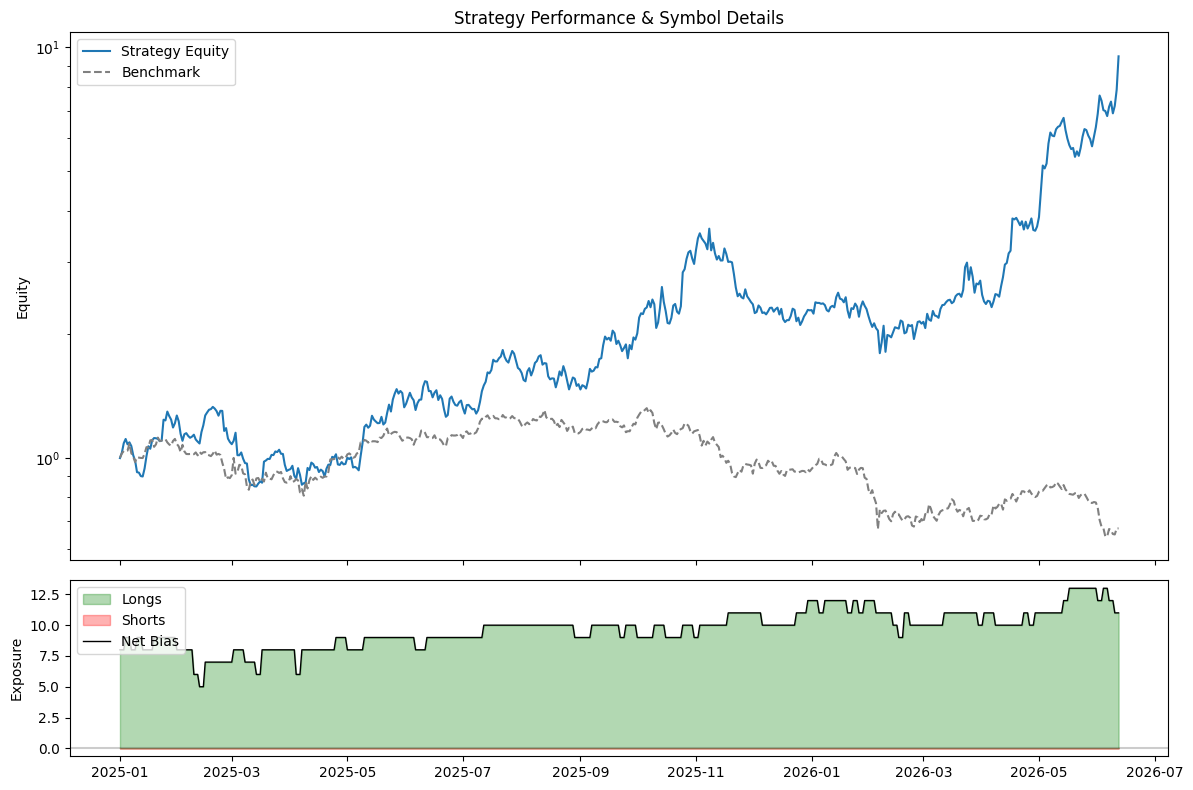

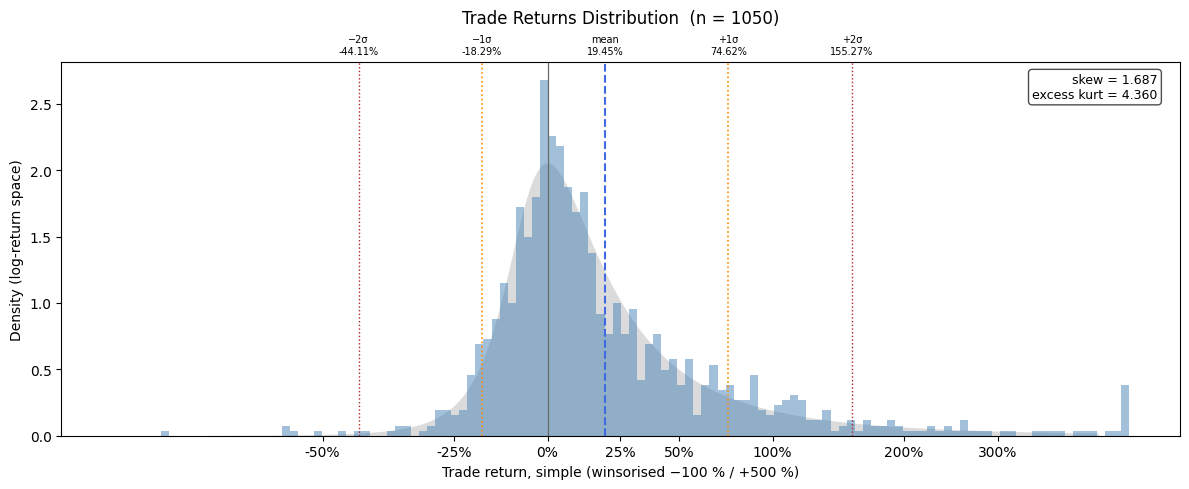

sortino: 4.481206806541356 (-0.7437101845554844)


ann_return: 1.656501211616193 (-0.19919507849586315)


win_rate: 0.6597520361133911 (None)


mae_std: 0.13631876467527282 (None)


mfe: 0.5863878901546105 (None)


...

maxdd: -0.35262962419407773 (-0.3472827557498151)


ann_std: 0.7313092910223917 (0.38373447777095887)


ir: 2.1894939392067774 (None)


mae: -0.11672894015928333 (None)


mfe_std: 1.2857589539413254 (None)


In [3]:
import datetime as dt
import polars as pl
import scrapbook as sb
import backtest as bt
import functools as fc
import operator

df = (
    pl.read_parquet("polarity/latest-data.parquet")
    .rename(
        {
            "asset": "symbol",
            "price": "close",
            'ts':'ts',
        }
    )
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us"))
    .sort(["symbol", "ts"])
    .with_columns(**{
        f'mom{n}': pl.col("close").pct_change(n).over("symbol")
        for n in set([days_momentum_score_P, *days_momentum_gate_P])
    })
    .with_columns(
        rank=(
            pl.col(f"mom{days_momentum_score_P}").rank(method="ordinal").over("ts")
            / pl.col(f"mom{days_momentum_score_P}").count().over("ts")
        ),
        volume=pl.col('total_volume').rolling_mean(days_holding_P).over('symbol'),
    )
    .sort("ts")
    .filter(pl.col("ts") .dt.year() >= 2025)
    .drop_nulls(['volume'])
)

class Alpha(bt.AlphaModel):
    def __init__(self, long_expr: pl.Expr, short_expr: pl.Expr):
        self.long_expr = long_expr
        self.short_expr = short_expr

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)
        l = dfnow.filter(self.long_expr)
        s = dfnow.filter(self.short_expr)

        return [
            bt.Signal(r['symbol'], True, r['rank'])
            for r in l.iter_rows(named=True)
        ] + [
            bt.Signal(r['symbol'], False, 1-r['rank'])
            for r in s.iter_rows(named=True)
        ]

if len(days_momentum_gate_P) > 0:
    long_gate_expr = fc.reduce(operator.or_, [pl.col(f'mom{n}') > 0 for n in days_momentum_gate_P]) & (pl.col('mkt') > -0.0)
    short_gate_expr = fc.reduce(operator.and_, [pl.col(f'mom{n}') < 0 for n in days_momentum_gate_P]) & (pl.col('mkt') < -0.15)
else:
    long_gate_expr = pl.lit(True)
    short_gate_expr = pl.lit(True)


test = bt.Backtest(
    df,
    alpha=Alpha(
        long_expr=(pl.col("rank") >= top_percentile_P) & long_gate_expr & (pl.col('volume') > min_volume_P),
        short_expr=(
            (pl.col("rank") <= bottom_percentile_P) & short_gate_expr & (pl.col('volume') > min_volume_P)
            if bottom_percentile_P is not None
            else pl.lit(False)
        ),
    ),
    benchmark="btc",
    period=days_holding_P,
    eager_rebalance=False,
)

test.run()
res = test.report(plot=True)

for col in set(res.columns) - {'year', 'src'}:
    s = res.filter(pl.col('src') == 'Strategy')
    b = res.filter(pl.col('src') == 'Benchmark')

    print(f"{col}: {s[col].mean()} ({b[col].mean()})")
    sb.glue(col,s[col].mean())

In [4]:
print(
    test.live(equity=10_000)
    .select(
        pl.col('entry_ts').dt.strftime('%Y-%m-%d'),
        pl.col('symbol').str.to_uppercase(),
        pl.lit(''),
        pl.col('entry_price'),
        pl.col('shares'),
        (pl.col('entry_price') * pl.col('shares')).alias('cost'),
    )
    .sort('symbol')
    .write_csv()
)

entry_ts,symbol,literal,entry_price,shares,cost
2026-06-12,BEAT,"",8.702512039483784,104.46304526397813,909.0909090909091
2026-06-12,BTW,"",0.07734276673277533,11754.052091669822,909.0909090909091
2026-06-12,DEXE,"",21.31136885516529,42.65755593970541,909.0909090909091
2026-06-12,HOME,"",0.030828353427599306,29488.792232316857,909.0909090909091
2026-06-12,LAB,"",8.824109623443242,103.0235284788058,909.0909090909091
2026-06-12,LIT,"",1.5773894849207386,576.3262135201754,909.0909090909091
2026-06-12,NEAR,"",2.06,441.306266548985,909.0909090909091
2026-06-12,RAIN,"",0.013266592937325372,68524.821209611,909.0909090909091
2026-06-12,VELVET,"",1.6741807713972394,543.0064211836569,909.090909090909
2026-06-12,VVV,"",14.735870489787525,61.692379131653,909.0909090909091
2026-06-12,WLD,"",0.5036387608532229,1805.045559938244,909.0909090909091

